In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!
Pandas version: 3.0.0
NumPy version: 2.4.2


In [2]:
# Load the generated traffic data
df = pd.read_csv('../data/raw/traffic_data.csv')

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("="*60)
print("DATA LOADED SUCCESSFULLY")
print("="*60)
print(f"\nDataset shape: {df.shape}")
print(f"Total records: {len(df):,}")
print(f"\nDate range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Number of routes: {df['route'].nunique()}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATA LOADED SUCCESSFULLY

Dataset shape: (490574, 14)
Total records: 490,574

Date range: 2024-01-01 00:00:00 to 2024-12-31 00:00:00
Number of routes: 14

Memory usage: 134.94 MB


In [3]:
# Display first few rows
print("="*60)
print("FIRST 10 RECORDS")
print("="*60)
display(df.head(10))

print("\n" + "="*60)
print("DATASET INFO")
print("="*60)
df.info()

FIRST 10 RECORDS


,timestamp,route,hour,day_of_week,day_name,is_weekend,is_holiday,month,weather,temperature,congestion_score,congestion_level,avg_speed_kmh,traffic_volume
0,2024-01-01,M1_North,0,0,Monday,False,True,1,Rain,25.052576,0.00,Low,120.00,55
1,2024-01-01,M1_South,0,0,Monday,False,True,1,Clear,11.375411,0.00,Low,120.00,0
2,2024-01-01,N1_North,0,0,Monday,False,True,1,Rain,16.852625,1.13,Low,116.99,0
3,2024-01-01,N1_South,0,0,Monday,False,True,1,Clear,21.878490,0.00,Low,120.00,0
4,2024-01-01,N3_East,0,0,Monday,False,True,1,Rain,19.972361,0.00,Low,119.51,0
5,2024-01-01,N3_West,0,0,Monday,False,True,1,Rain,20.984306,2.67,Low,111.98,0
6,2024-01-01,M2_East,0,0,Monday,False,True,1,Clear,23.868502,0.00,Low,116.97,0
7,2024-01-01,M2_West,0,0,Monday,False,True,1,Clear,18.074589,0.00,Low,114.71,64
8,2024-01-01,William_Nicol,0,0,Monday,False,True,1,Clear,24.471662,0.00,Low,120.00,177
9,2024-01-01,Rivonia_Road,0,0,Monday,False,True,1,Clear,24.877726,0.00,Low,119.07,66



DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 490574 entries, 0 to 490573
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   timestamp         490574 non-null  datetime64[us]
 1   route             490574 non-null  str           
 2   hour              490574 non-null  int64         
 3   day_of_week       490574 non-null  int64         
 4   day_name          490574 non-null  str           
 5   is_weekend        490574 non-null  bool          
 6   is_holiday        490574 non-null  bool          
 7   month             490574 non-null  int64         
 8   weather           490574 non-null  str           
 9   temperature       490574 non-null  float64       
 10  congestion_score  490574 non-null  float64       
 11  congestion_level  490574 non-null  str           
 12  avg_speed_kmh     490574 non-null  float64       
 13  traffic_volume    490574 non-null  int64         
dtypes

In [4]:
# Statistical summary
print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)
display(df.describe())

print("\n" + "="*60)
print("CATEGORICAL VARIABLES SUMMARY")
print("="*60)
print(f"\nRoutes:\n{df['route'].value_counts()}")
print(f"\nWeather Conditions:\n{df['weather'].value_counts()}")
print(f"\nCongestion Levels:\n{df['congestion_level'].value_counts()}")
print(f"\nDay of Week Distribution:\n{df['day_name'].value_counts()}")

STATISTICAL SUMMARY


,timestamp,hour,day_of_week,month,temperature,congestion_score,avg_speed_kmh,traffic_volume
count,490574,490574.000000,490574.000000,490574.000000,490574.000000,490574.000000,490574.000000,490574.000000
mean,2024-07-01 12:00:00,11.499672,2.991724,6.498787,19.991827,31.889705,94.342798,1603.513344
min,2024-01-01 00:00:00,0.000000,0.000000,1.000000,-3.439114,0.000000,31.310000,0.000000
25%,2024-04-01 06:00:00,5.000000,1.000000,4.000000,16.621031,12.090000,78.470000,593.000000
50%,2024-07-01 12:00:00,11.000000,3.000000,7.000000,19.986617,26.500000,98.510000,1344.000000
75%,2024-09-30 18:00:00,17.000000,5.000000,9.000000,23.363704,52.060000,110.510000,2593.000000
max,2024-12-31 00:00:00,23.000000,6.000000,12.000000,42.137845,100.000000,120.000000,5427.000000
std,NaN,6.922367,2.003407,3.444054,5.002587,24.151434,19.344326,1210.085712



CATEGORICAL VARIABLES SUMMARY

Routes:
route
M1_North          35041
M1_South          35041
N1_North          35041
N1_South          35041
N3_East           35041
N3_West           35041
M2_East           35041
M2_West           35041
William_Nicol     35041
Rivonia_Road      35041
Jan_Smuts         35041
Sandton_Drive     35041
Pretoria_Main     35041
Soweto_Highway    35041
Name: count, dtype: int64

Weather Conditions:
weather
Clear      294019
Cloudy      98194
Rain        73830
Drizzle     24531
Name: count, dtype: int64

Congestion Levels:
congestion_level
Low         266353
Moderate    135218
High         89003
Name: count, dtype: int64

Day of Week Distribution:
day_name
Monday       71232
Tuesday      69902
Wednesday    69888
Thursday     69888
Friday       69888
Saturday     69888
Sunday       69888
Name: count, dtype: int64


In [5]:
# Check for missing values
print("="*60)
print("MISSING VALUES CHECK")
print("="*60)

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})

print(missing_df[missing_df['Missing Values'] > 0])

if missing_df['Missing Values'].sum() == 0:
    print("\n✓ No missing values found! Data is clean.")
else:
    print(f"\n⚠ Found {missing_df['Missing Values'].sum()} missing values")

MISSING VALUES CHECK
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []

✓ No missing values found! Data is clean.


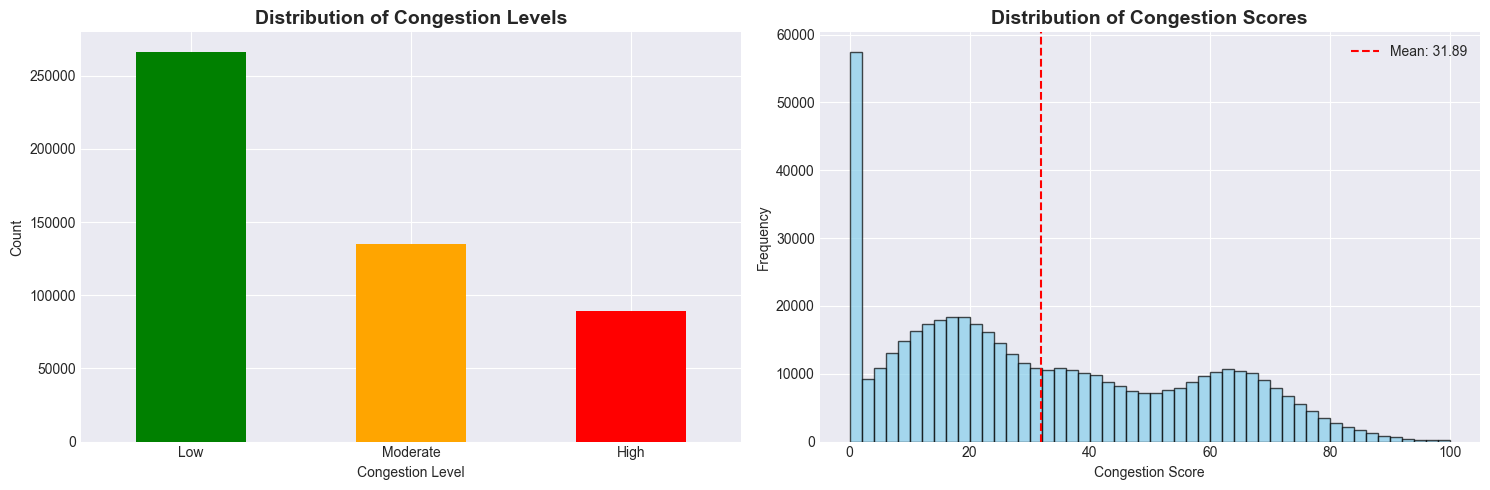

Mean Congestion Score: 31.89
Median Congestion Score: 26.50
Std Deviation: 24.15


In [6]:
# Visualize congestion level distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Congestion level counts
df['congestion_level'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'orange', 'red'])
axes[0].set_title('Distribution of Congestion Levels', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Congestion Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Congestion score distribution
axes[1].hist(df['congestion_score'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Congestion Scores', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Congestion Score')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['congestion_score'].mean(), color='red', linestyle='--', label=f'Mean: {df["congestion_score"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean Congestion Score: {df['congestion_score'].mean():.2f}")
print(f"Median Congestion Score: {df['congestion_score'].median():.2f}")
print(f"Std Deviation: {df['congestion_score'].std():.2f}")

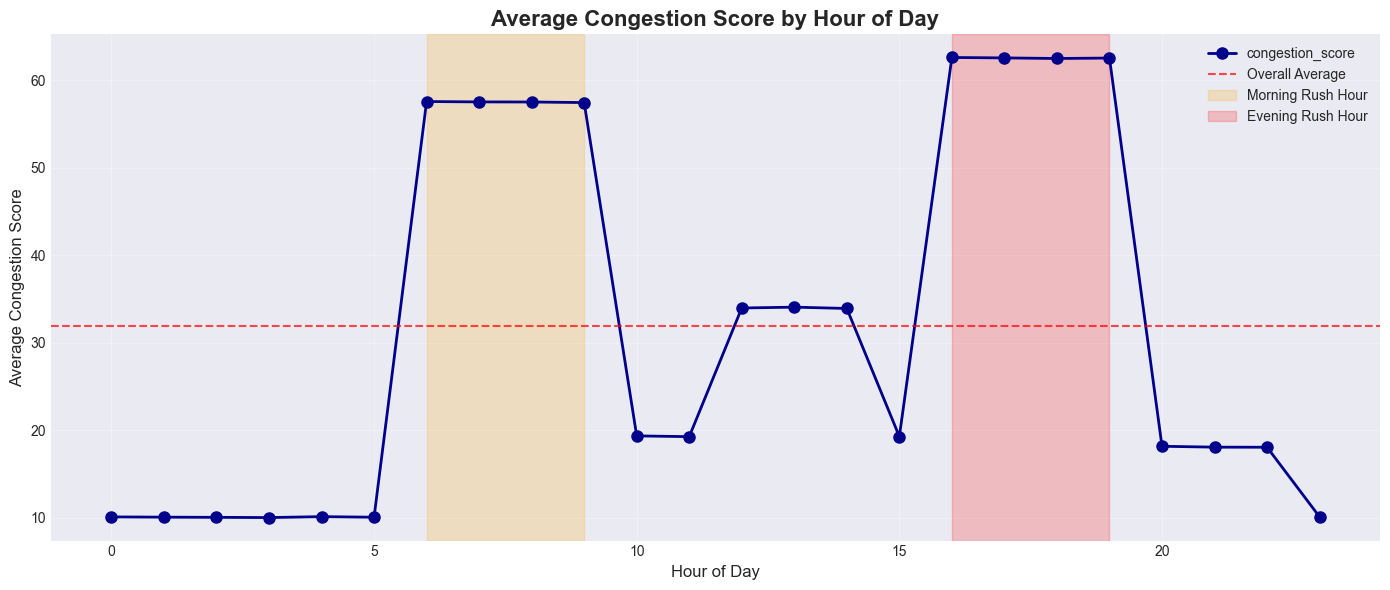

Peak congestion hours:
hour
16    62.627818
17    62.578878
19    62.561962
18    62.512463
6     57.592033
Name: congestion_score, dtype: float64


In [7]:
# Average congestion by hour of day
hourly_congestion = df.groupby('hour')['congestion_score'].mean()

fig, ax = plt.subplots(figsize=(14, 6))
hourly_congestion.plot(kind='line', marker='o', linewidth=2, markersize=8, ax=ax, color='darkblue')
ax.set_title('Average Congestion Score by Hour of Day', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Average Congestion Score', fontsize=12)
ax.grid(True, alpha=0.3)
ax.axhline(y=df['congestion_score'].mean(), color='red', linestyle='--', label='Overall Average', alpha=0.7)

# Highlight rush hours
ax.axvspan(6, 9, alpha=0.2, color='orange', label='Morning Rush Hour')
ax.axvspan(16, 19, alpha=0.2, color='red', label='Evening Rush Hour')
ax.legend()

plt.tight_layout()
plt.show()

print("Peak congestion hours:")
print(hourly_congestion.nlargest(5))

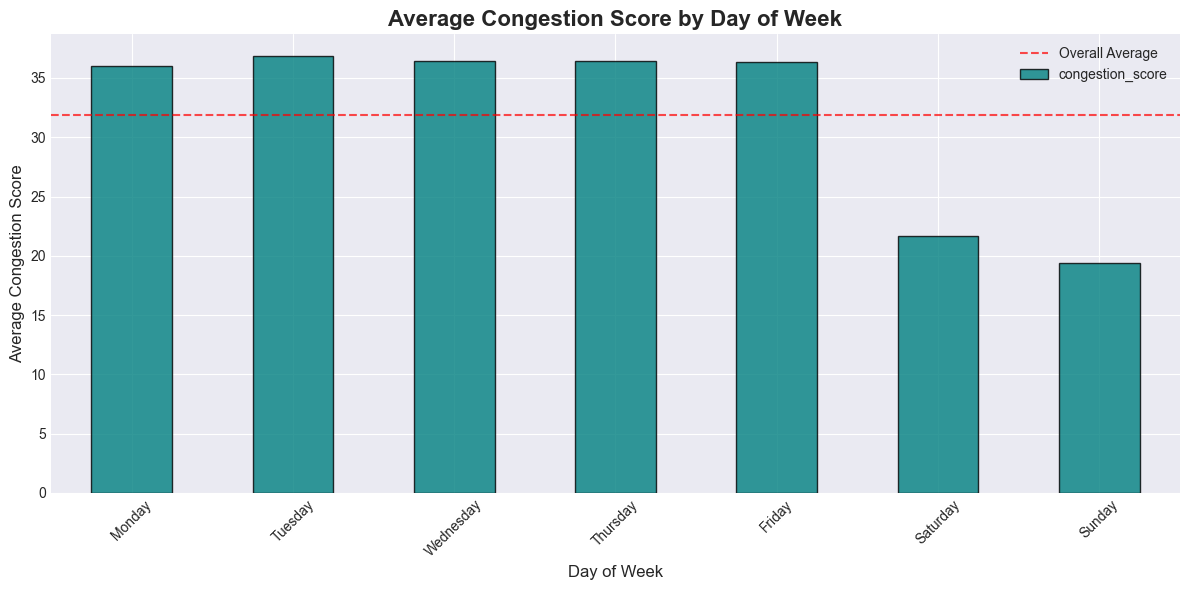

Average congestion by day:
day_name
Monday       36.017782
Tuesday      36.829064
Wednesday    36.417537
Thursday     36.437073
Friday       36.386246
Saturday     21.699354
Sunday       19.360502
Name: congestion_score, dtype: float64


In [8]:
# Average congestion by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_congestion = df.groupby('day_name')['congestion_score'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(12, 6))
daily_congestion.plot(kind='bar', ax=ax, color='teal', edgecolor='black', alpha=0.8)
ax.set_title('Average Congestion Score by Day of Week', fontsize=16, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Congestion Score', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=df['congestion_score'].mean(), color='red', linestyle='--', label='Overall Average', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

print("Average congestion by day:")
print(daily_congestion)

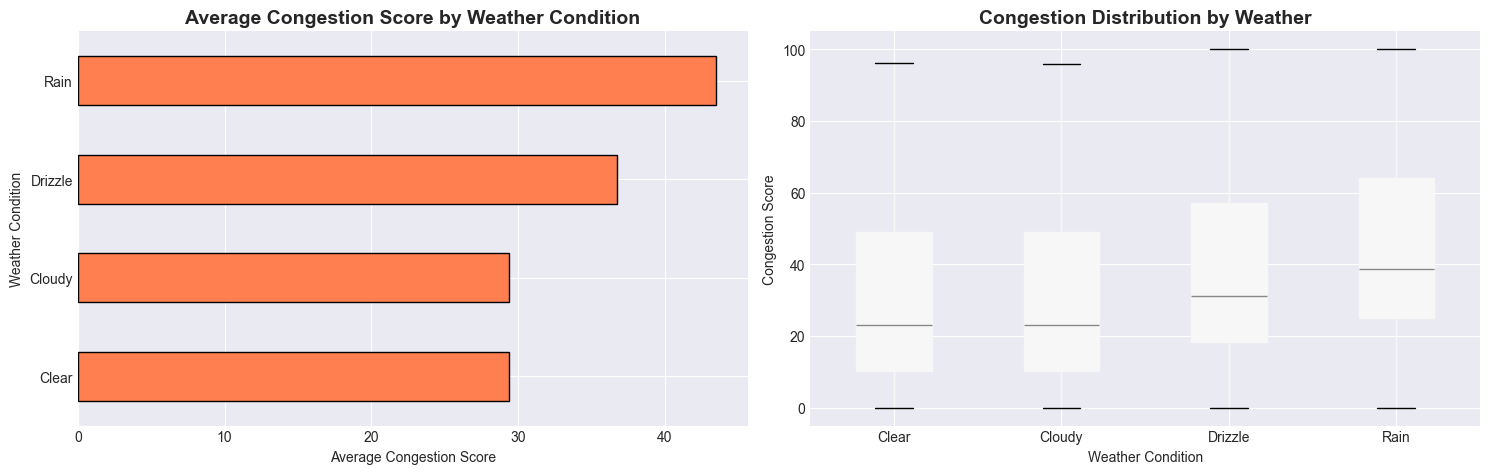

Weather impact statistics:
          mean  median    std
weather                      
Clear    29.40   23.15  23.32
Cloudy   29.42   23.14  23.33
Drizzle  36.73   31.18  24.35
Rain     43.49   38.60  24.80


In [9]:
# Weather impact on congestion
weather_congestion = df.groupby('weather')['congestion_score'].agg(['mean', 'median', 'std']).round(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
weather_congestion['mean'].sort_values().plot(kind='barh', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Average Congestion Score by Weather Condition', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Congestion Score')
axes[0].set_ylabel('Weather Condition')

# Box plot
df.boxplot(column='congestion_score', by='weather', ax=axes[1], patch_artist=True)
axes[1].set_title('Congestion Distribution by Weather', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Weather Condition')
axes[1].set_ylabel('Congestion Score')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

print("Weather impact statistics:")
print(weather_congestion)

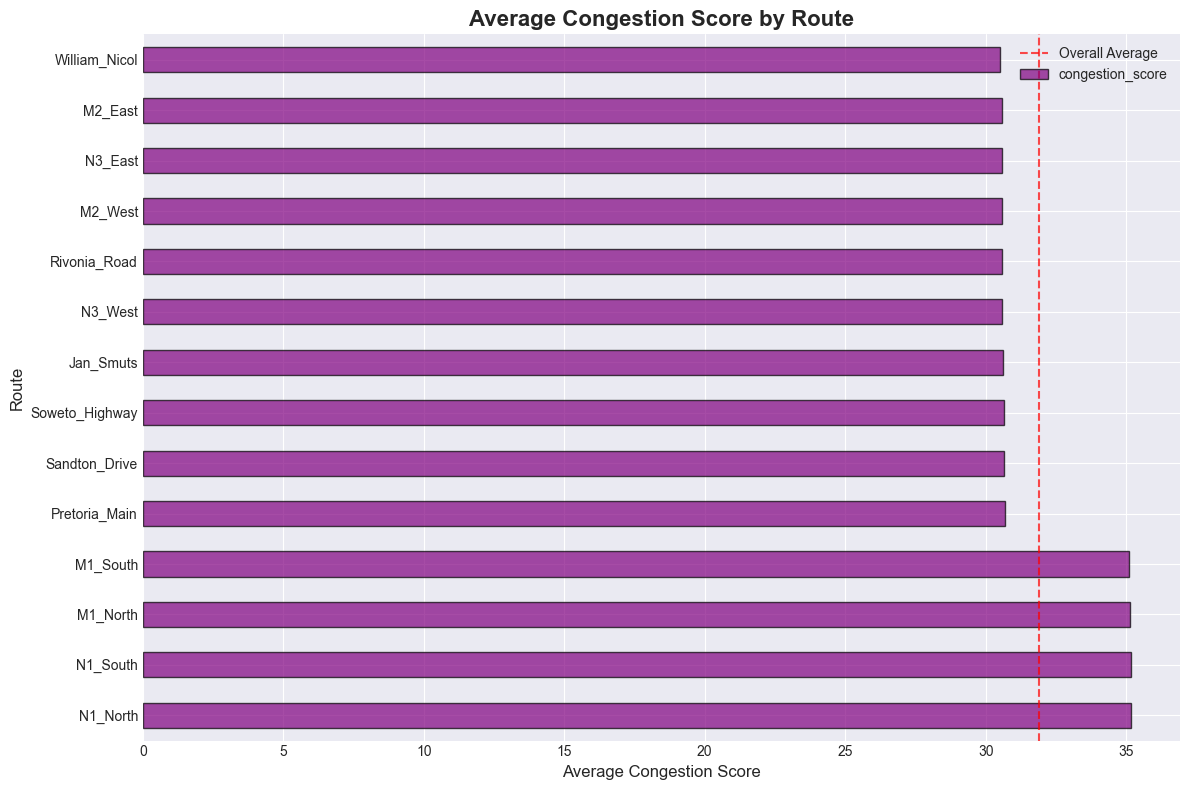

Top 5 most congested routes:
route
N1_North         35.156742
N1_South         35.155685
M1_North         35.119520
M1_South         35.090337
Pretoria_Main    30.674340
Name: congestion_score, dtype: float64

Top 5 least congested routes:
route
Rivonia_Road     30.573274
M2_West          30.571954
N3_East          30.566987
M2_East          30.566928
William_Nicol    30.501013
Name: congestion_score, dtype: float64


In [10]:
# Compare congestion across different routes
route_congestion = df.groupby('route')['congestion_score'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
route_congestion.plot(kind='barh', ax=ax, color='purple', edgecolor='black', alpha=0.7)
ax.set_title('Average Congestion Score by Route', fontsize=16, fontweight='bold')
ax.set_xlabel('Average Congestion Score', fontsize=12)
ax.set_ylabel('Route', fontsize=12)
ax.axvline(x=df['congestion_score'].mean(), color='red', linestyle='--', label='Overall Average', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

print("Top 5 most congested routes:")
print(route_congestion.head())
print("\nTop 5 least congested routes:")
print(route_congestion.tail())

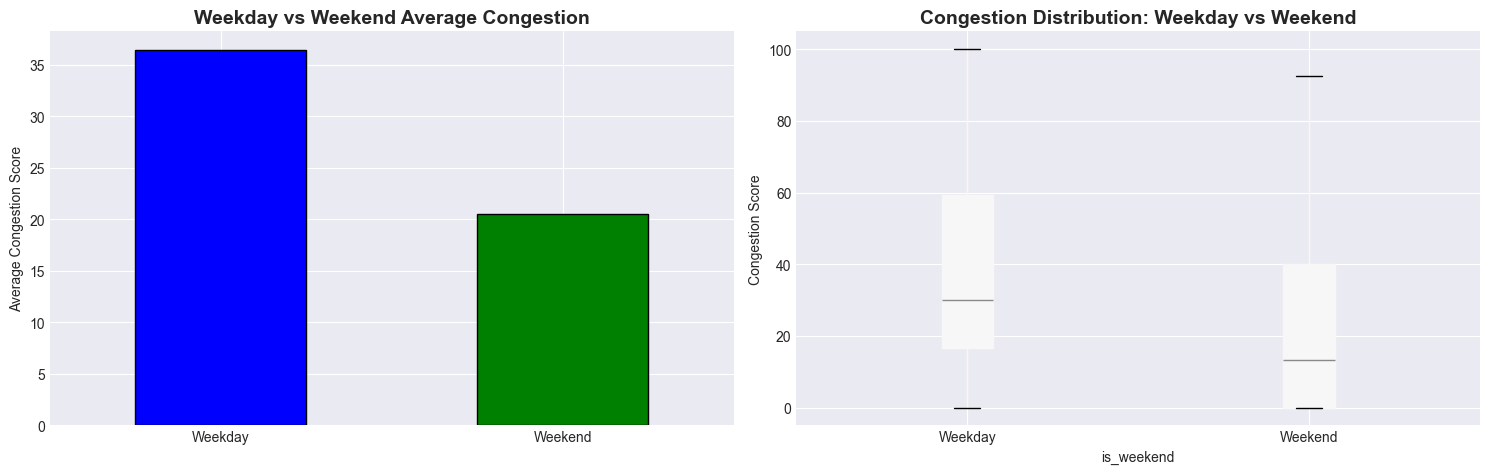

Weekend vs Weekday Statistics:
          mean  median    std
Weekday  36.42   29.89  23.87
Weekend  20.53   13.20  20.89


In [11]:
# Weekend vs Weekday comparison
weekend_comparison = df.groupby('is_weekend')['congestion_score'].agg(['mean', 'median', 'std']).round(2)
weekend_comparison.index = ['Weekday', 'Weekend']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar comparison
weekend_comparison['mean'].plot(kind='bar', ax=axes[0], color=['blue', 'green'], edgecolor='black')
axes[0].set_title('Weekday vs Weekend Average Congestion', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Congestion Score')
axes[0].tick_params(axis='x', rotation=0)

# Box plot comparison
df.boxplot(column='congestion_score', by='is_weekend', ax=axes[1], patch_artist=True)
axes[1].set_title('Congestion Distribution: Weekday vs Weekend', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Weekday', 'Weekend'])
axes[1].set_ylabel('Congestion Score')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Weekend vs Weekday Statistics:")
print(weekend_comparison)

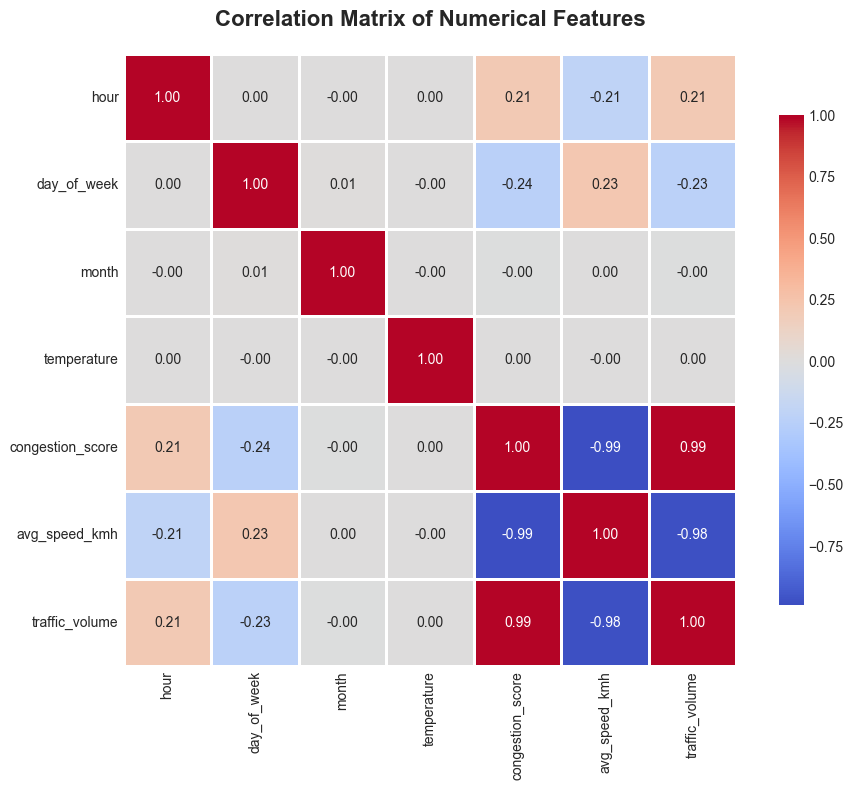

Key correlations with congestion_score:
congestion_score    1.000000
traffic_volume      0.987296
hour                0.211986
temperature         0.000617
month              -0.004452
day_of_week        -0.237027
avg_speed_kmh      -0.988810
Name: congestion_score, dtype: float64


In [12]:
# Correlation heatmap
numeric_cols = ['hour', 'day_of_week', 'month', 'temperature', 
                'congestion_score', 'avg_speed_kmh', 'traffic_volume']

correlation_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("Key correlations with congestion_score:")
congestion_corr = correlation_matrix['congestion_score'].sort_values(ascending=False)
print(congestion_corr)

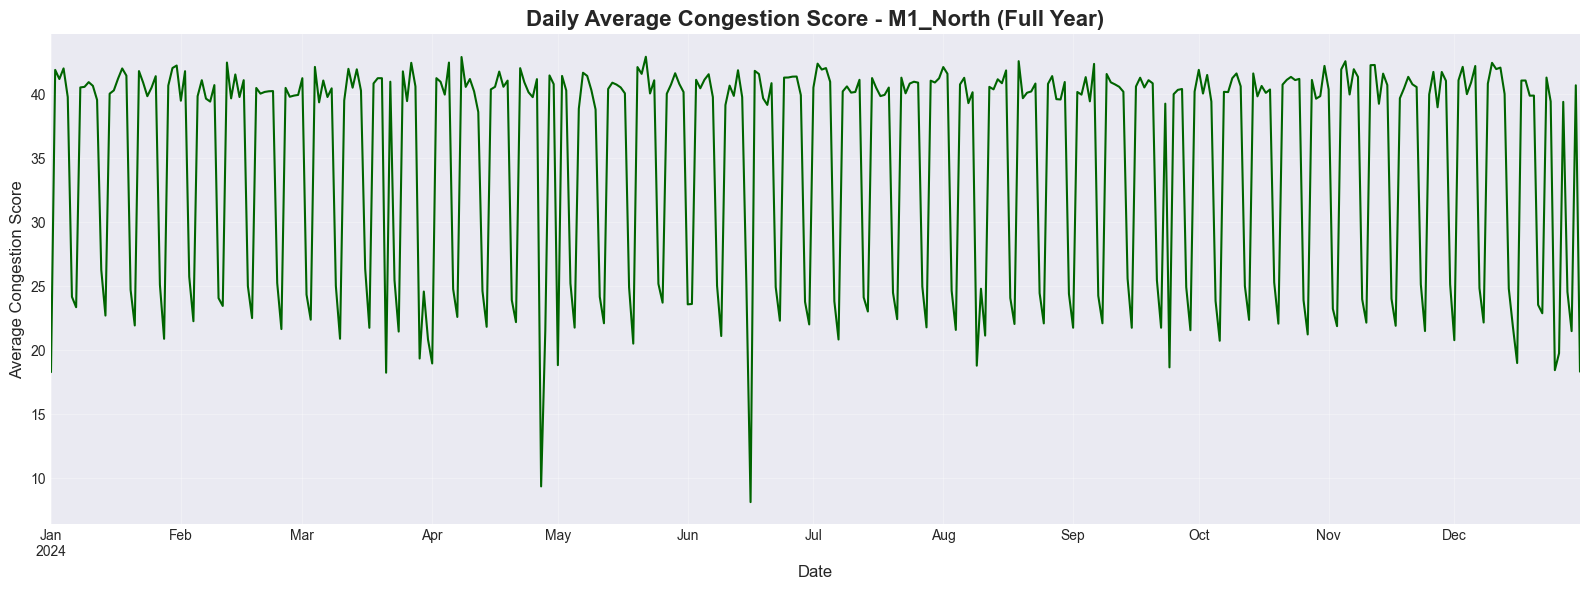

Statistics for M1_North:
Mean: 35.12
Max: 100.00
Min: 0.00


In [13]:
# Sample one route for time series visualization
sample_route = 'M1_North'
route_data = df[df['route'] == sample_route].copy()
route_data = route_data.set_index('timestamp')

# Resample to daily average for cleaner visualization
daily_avg = route_data['congestion_score'].resample('D').mean()

fig, ax = plt.subplots(figsize=(16, 6))
daily_avg.plot(ax=ax, linewidth=1.5, color='darkgreen')
ax.set_title(f'Daily Average Congestion Score - {sample_route} (Full Year)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Average Congestion Score', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Statistics for {sample_route}:")
print(f"Mean: {route_data['congestion_score'].mean():.2f}")
print(f"Max: {route_data['congestion_score'].max():.2f}")
print(f"Min: {route_data['congestion_score'].min():.2f}")

In [14]:
print("="*80)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("="*80)

print("\n1. DATASET OVERVIEW:")
print(f"   • Total records: {len(df):,}")
print(f"   • Time period: Full year 2024")
print(f"   • Number of routes: {df['route'].nunique()}")
print(f"   • Data points per route: {len(df) // df['route'].nunique():,}")

print("\n2. CONGESTION PATTERNS:")
print(f"   • Average congestion score: {df['congestion_score'].mean():.2f}")
print(f"   • Peak hours: 6-9 AM and 4-7 PM")
print(f"   • Most congested day: {daily_congestion.idxmax()}")
print(f"   • Least congested day: {daily_congestion.idxmin()}")

print("\n3. WEATHER IMPACT:")
print(f"   • Highest congestion weather: {weather_congestion['mean'].idxmax()}")
print(f"   • Lowest congestion weather: {weather_congestion['mean'].idxmin()}")

print("\n4. ROUTE ANALYSIS:")
print(f"   • Most congested route: {route_congestion.idxmax()} ({route_congestion.max():.2f})")
print(f"   • Least congested route: {route_congestion.idxmin()} ({route_congestion.min():.2f})")

print("\n5. WEEKEND EFFECT:")
weekend_diff = weekend_comparison.loc['Weekday', 'mean'] - weekend_comparison.loc['Weekend', 'mean']
print(f"   • Weekdays are {weekend_diff:.2f} points more congested than weekends")

print("\n6. DATA QUALITY:")
print(f"   • Missing values: {df.isnull().sum().sum()}")
print(f"   • Duplicate rows: {df.duplicated().sum()}")
print(f"   • Data quality: ✓ Excellent")

print("\n" + "="*80)
print("READY FOR MODEL DEVELOPMENT")
print("="*80)

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. DATASET OVERVIEW:
   • Total records: 490,574
   • Time period: Full year 2024
   • Number of routes: 14
   • Data points per route: 35,041

2. CONGESTION PATTERNS:
   • Average congestion score: 31.89
   • Peak hours: 6-9 AM and 4-7 PM
   • Most congested day: Tuesday
   • Least congested day: Sunday

3. WEATHER IMPACT:
   • Highest congestion weather: Rain
   • Lowest congestion weather: Clear

4. ROUTE ANALYSIS:
   • Most congested route: N1_North (35.16)
   • Least congested route: William_Nicol (30.50)

5. WEEKEND EFFECT:
   • Weekdays are 15.89 points more congested than weekends

6. DATA QUALITY:
   • Missing values: 0
   • Duplicate rows: 0
   • Data quality: ✓ Excellent

READY FOR MODEL DEVELOPMENT
